In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tifffile as tiff
import os
import pandas as pd
from PIL import Image
import torch
import math

(10012, 10012)


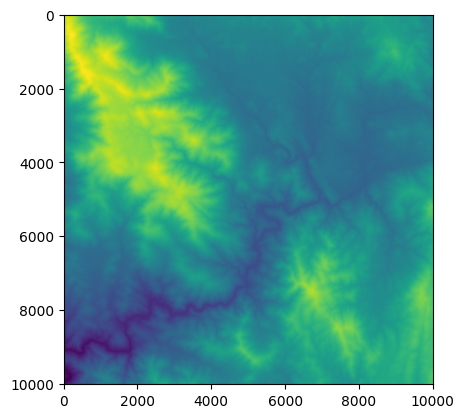

In [76]:
path = 'data/USGS_1M_10_x76y415_CA_SierraNevada_B22.tif'
img = tiff.imread(path)
arr = np.array(img)
print(arr.shape)
plt.imshow(img)

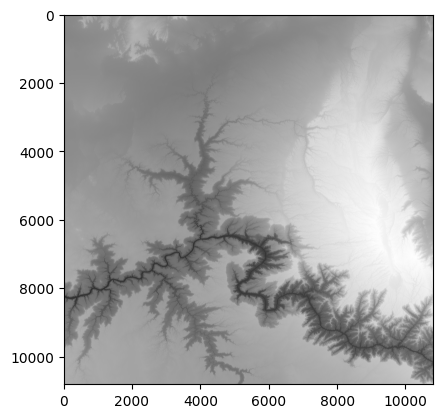

In [71]:
arr_png = (arr / np.max(arr)) * 255
arr_png = arr_png.astype(np.int16)
img = Image.fromarray(arr_png)
plt.imshow(img)

629.16394 1956.1891


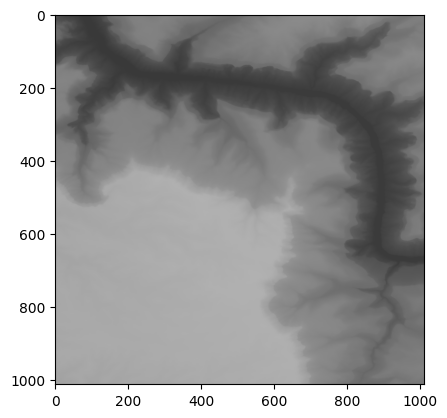

In [75]:
y = 8000
x = 5000
size = 1012
og_slice = arr[y:y+size, x:x+size]
scaled = (og_slice / np.max(arr)) * 255
og_slice_img = Image.fromarray(scaled)
print(og_slice.min(), og_slice.max())
plt.imshow(og_slice_img)

57 177


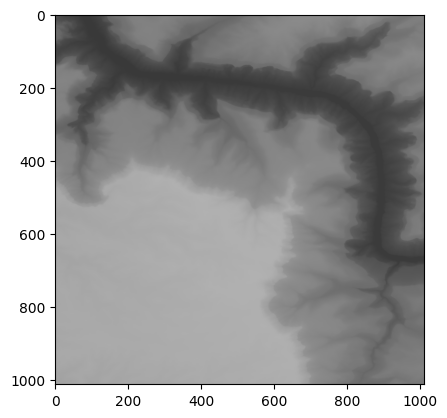

In [73]:
png_slice = arr_png[y:y+size, x:x+size]
png_slice_img = Image.fromarray(png_slice)
print(png_slice.min(), png_slice.max())
plt.imshow(png_slice_img)

(array([  469479.,  2147157.,  5392566., 20414689., 26553904., 18289312.,
        11940856.,  7012939.,  6598217.,  1421025.]),
 array([212.21578979, 278.52734375, 344.83886719, 411.15039062,
        477.46194458, 543.7734375 , 610.08502197, 676.39660645,
        742.70812988, 809.01965332, 875.33117676]),
 <BarContainer object of 10 artists>)

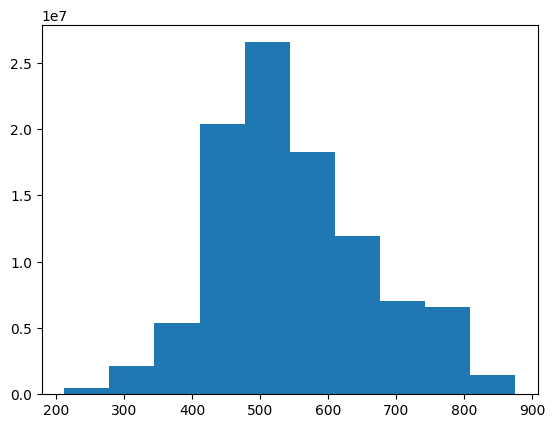

In [10]:
arr_flat = arr.flatten()
plt.hist(arr_flat)

In [67]:
size = 1024
(arr.shape[0] / size) ** 2

111.48390197753906

In [66]:
path = 'data/USGS_13_n37w113_20250805.tif'
img = tiff.imread(path)
arr = np.array(img)
arr.shape

(10812, 10812)

(array([1206.,  698.,  501.,  263.,  241.,  239.,  204.,  201.,  384.,
         159.]),
 array([ 71. ,  75.7,  80.4,  85.1,  89.8,  94.5,  99.2, 103.9, 108.6,
        113.3, 118. ]),
 <BarContainer object of 10 artists>)

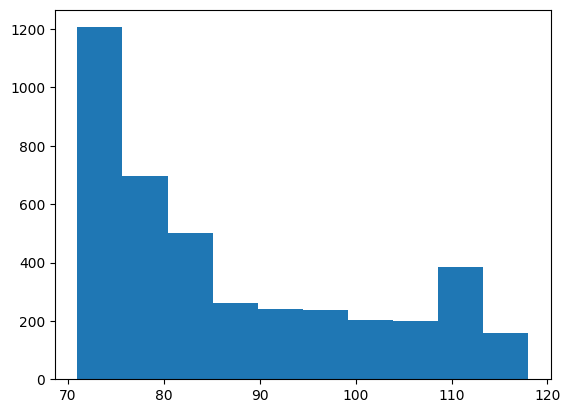

In [ ]:
image = np.array(Image.open('/home/lin/maskGIT/data/test_geo/2.png')).flatten()
plt.hist(image)


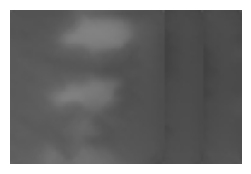

In [59]:
i_0 = Image.open('/home/lin/maskGIT/results/test_transformer_best_99/output0.png')
i_1 = Image.open('/home/lin/maskGIT/results/test_transformer_best_99/output1.png')
i_2 = Image.open('/home/lin/maskGIT/results/test_transformer_best_99/output2.png')

def compose_squares(a, b, c, i, overlap=0.5):
    """
    a, b, c: PIL.Image or np.ndarray, shape (H, W*count, ...)
    i: integer index in [0, count-1]
    overlap: float, in (0, 1), proportion of the patch width to overlap
    Output: Displays a stitched image of [a square | b right overlap | c right overlap]
    """
    import numpy as np
    from PIL import Image
    import matplotlib.pyplot as plt

    # Clamp overlap to valid range
    overlap = min(max(float(overlap), 0), 1)
    if not (0 < overlap < 1):
        raise ValueError("overlap must be between 0 and 1 (exclusive)")

    # Ensure arrays
    a_arr = np.array(a)
    b_arr = np.array(b)
    c_arr = np.array(c)

    # Infer patch size from shape
    # If shape is (H, W*count, ...) and count >= i, patch width is W
    if a_arr.ndim == 2:
        W = a_arr.shape[1] // (a_arr.shape[1] // 64)  # fallback to 64
        H = a_arr.shape[0]
    else:
        W = a_arr.shape[1] // (a_arr.shape[1] // 64)
        H = a_arr.shape[0]

    patch_width = W
    overlap_px = int(round(patch_width * overlap))

    idx = i

    def extract_square(img_arr, idx):
        start = idx * patch_width
        end = start + patch_width
        if img_arr.ndim == 2:
            return img_arr[:, start:end]
        elif img_arr.ndim == 3:
            return img_arr[:, start:end, :]
        else:
            raise ValueError("Unsupported image array dimensions")

    def extract_right_overlap(img_arr, idx):
        start = idx * patch_width + (patch_width - overlap_px)
        end = idx * patch_width + patch_width
        if img_arr.ndim == 2:
            return img_arr[:, start:end]
        elif img_arr.ndim == 3:
            return img_arr[:, start:end, :]
        else:
            raise ValueError("Unsupported image array dimensions")

    sq_a = extract_square(a_arr, idx)
    right_b = extract_right_overlap(b_arr, idx)
    right_c = extract_right_overlap(c_arr, idx)

    # Concatenate: [a | right_b | right_c]
    if sq_a.ndim == 2:
        result = np.concatenate([sq_a, right_b, right_c], axis=1)
    else:
        result = np.concatenate([sq_a, right_b, right_c], axis=1)

    # Display result
    out_width = patch_width + 2 * overlap_px
    plt.figure(figsize=(out_width // 16, H // 32))
    if result.ndim == 2:
        plt.imshow(result, cmap='viridis')
    else:
        plt.imshow(result)
    plt.axis('off')
    plt.show()

# Example usage:
compose_squares(np.array(i_0), np.array(i_1), np.array(i_2), 2, overlap=0.25)